In [13]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import cross_val_score

In [14]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

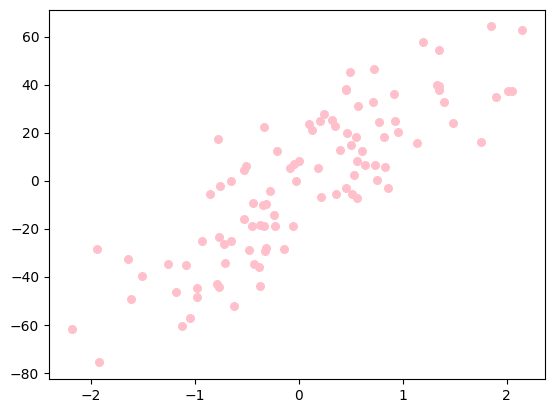

In [15]:
plt.scatter(X,y , color='pink', marker='o', s=30)

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [17]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [18]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
lr.coef_, lr.intercept_

(array([28.12597332]), np.float64(-2.2710144261783825))

In [20]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [45]:
class myGD:
    
    def __init__(self, learning_rate, epochs):
        self.m =50   #assume anything
        self.b = 100  #assume anything 
        self.learning_rate = learning_rate
        self.epochs = epochs
        
    def fit(self, X, y):
        
        for i in range( self.epochs):
            
            loss_slope_b = -2 * (np.sum(y-self.m*X.ravel()-self.b))
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())
            
            self.b = self.b - (self.learning_rate*loss_slope_b)
            self.m = self.m - (self.learning_rate*loss_slope_m)
            
        print(self.m,self.b)
    
    def predict(self, X):
        return self.m*X + self.b
        


In [53]:
gd = myGD(0.1, 100)

b =gd.fit(X,y)
print(b)

2.9509202422418583e+130 7.617114024459552e+130
None


In [46]:
gd = myGD(0.01, 50)

b =gd.fit(X_train,y_train)
print(b)

28.125973337439376 -2.2710143898208353
None


In [47]:
y_pred = gd.predict(X_test)
# r2_score(y_test,y_pred) 


In [48]:
r2_score(y_test,y_pred)

0.6345158781400441